# Class Project: Chronic Disease Analysis
## Part 2: Data Exploratory Analysis and Visualization

This notebook expands on Part 1 by performing exploratory data analysis and producing visualizations for three objectives:
1. **Chronic Disease Prevalence** - National and State-level prevalence stratified by age and race
2. **Medicare Utilization Analysis** - Utilization metrics across conditions at national and state levels
3. **State-wise Prevalence Analysis** - Top/bottom states per condition compared to the national average, stratified by gender and race

---
## Setup: Import Libraries and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import numpy as np

df = pd.read_csv('chronic-disease-data.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Dataset shape: (32340, 12)
Columns: ['Bene_Geo_Lvl', 'Bene_Geo_Desc', 'Bene_Geo_Cd', 'Bene_Age_Lvl', 'Bene_Demo_Lvl', 'Bene_Demo_Desc', 'Bene_Cond', 'Prvlnc', 'Tot_Mdcr_Stdzd_Pymt_PC', 'Tot_Mdcr_Pymt_PC', 'Hosp_Readmsn_Rate', 'ER_Visits_Per_1000_Benes']


,Bene_Geo_Lvl,Bene_Geo_Desc,Bene_Geo_Cd,Bene_Age_Lvl,Bene_Demo_Lvl,Bene_Demo_Desc,Bene_Cond,Prvlnc,Tot_Mdcr_Stdzd_Pymt_PC,Tot_Mdcr_Pymt_PC,Hosp_Readmsn_Rate,ER_Visits_Per_1000_Benes
0,State,Alabama,1.0,All,All,All,Alcohol Abuse,0.0188,25102.3405,23348.6039,0.2413,2184.7557
1,State,Alabama,1.0,65+,Dual Status,Medicare Only,Alcohol Abuse,0.0118,NaN,NaN,NaN,NaN
2,State,Alabama,1.0,<65,Dual Status,Medicare Only,Alcohol Abuse,0.0320,NaN,NaN,NaN,NaN


---
## Objective 1: Chronic Disease Prevalence

### Overview
This section examines the prevalence of 21 chronic conditions among Medicare fee-for-service beneficiaries. The analysis covers the **national level** as well as four target states - **Texas, New York, California, and Florida** - stratified by **age group** ('<65' vs '65+') and **race** (Asian Pacific Islander, Hispanic, Native American, non-Hispanic Black, non-Hispanic White).

### Visualization: Faceted Heatmap - Prevalence by Race and Age Group

The heatmap below shows the prevalence of each chronic condition (rows) broken down by racial group (columns). Each panel represents one geography (National, CA, FL, NY, TX), and the two rows of panels correspond to the two age groups ('65+' on top, '<65' on bottom). Color intensity encodes prevalence: darker cells indicate higher rates within that panel.

**Key Observations to look for:**
- Hypertension and Hyperlipidemia are consistently the most prevalence conditions in the '65+' age group across all geographies and racial groups, with both of them notably dark for non-Hispanic Black beneficiaries. This indicates a strong racial disparity in cardiovascular disease burden among older Medicare patients.
- In the '<65' age group, the overall color intensity is lower, but Drug/Substance Abuse, HIV/AIDS, and Schizophrenia show relatively higher prevalence compared to the '65+' panels, suggesting these conditions disproportionately affect younger Medicare beneficiaries.
- White cells (missing data) appear most frequently for Native American and Asian/Pacific Islander subgroups in certain states, reflecting smaller population sizes in those states that may suppress reporting.
- The National panel serves as a useful visual baseline as most state panels follow similar patterns.

#### Data Preparations 

In [2]:
# Filter to race-stratified data for national level and 4 target states
target_geos = ['National', 'California', 'Florida', 'New York', 'Texas']
age_groups = ['65+', '<65']
race_groups = ['Asian Pacific Islander', 'Hispanic', 'Native American', 'non-Hispanic Black', 'non-Hispanic White']

In [3]:
# Extract data
prevalence_subset_df = df[
    (df['Bene_Demo_Lvl'] == 'Race') &
    (df['Bene_Demo_Desc'].isin(race_groups)) &
    (df['Bene_Age_Lvl'].isin(age_groups)) &
    (
        ((df['Bene_Geo_Lvl'] == 'National')) |
        ((df['Bene_Geo_Lvl'] == 'State') & (df['Bene_Geo_Desc'].isin(target_geos)))
    )
]

#### Heatmap

In [4]:
# Setting up the Plot
fig, axes = plt.subplots(
    nrows = len(age_groups), ncols = len(target_geos),
    figsize=(22, 14)
)

In [5]:
# Creating the Plot
for row_idx, age in enumerate(age_groups):
    for col_idx, geo in enumerate(target_geos):
        mini_plot = axes[row_idx][col_idx]

        subset = prevalence_subset_df[
            (prevalence_subset_df['Bene_Age_Lvl'] == age) &
            (prevalence_subset_df['Bene_Geo_Desc'] == geo)
        ]

        # Pivot to Conditions x Race
        pivot = subset.pivot_table(
            index = 'Bene_Cond', columns = 'Bene_Demo_Desc', values = 'Prvlnc', aggfunc = 'mean'
        ).reindex(index = sorted(prevalence_subset_df['Bene_Cond'].unique()), columns = race_groups)

        # y-axis labels (conditions) on the first column
        show_yticklabels = (col_idx == 0)
        # colorbar on the last column
        show_cbar = (col_idx == len(target_geos) - 1)

        sns.heatmap(pivot, 
            ax = mini_plot, cmap = 'YlOrRd',
            vmin = 0, vmax = prevalence_subset_df['Prvlnc'].max(),
            linewidths = 0.3, linecolor = 'white', 
            annot = False,
            cbar = show_cbar,
            yticklabels = show_yticklabels, xticklabels = True
        )

        if show_cbar:
            cbar = mini_plot.collections[0].colorbar
            cbar.set_label('Prevalence', fontsize = 9)

        # Titles and labels
        # Top row gets column titles (geographies)
        if row_idx == 0: mini_plot.set_title(geo, fontsize = 12, fontweight = 'bold', pad = 6)
        # Removes repetitive axis labels
        mini_plot.set_xlabel('')
        mini_plot.set_ylabel('')
        # Rotates race labels for readability
        mini_plot.tick_params(axis = 'x', rotation = 45, labelsize = 8)
        if show_yticklabels: mini_plot.tick_params(axis = 'y', rotation = 0, labelsize = 7.5)

# Row labels for age groups
for row_idx, age in enumerate(age_groups):
    axes[row_idx][0].set_ylabel(
        f'Age {age}', fontsize=11, fontweight='bold', labelpad=8
    )
# Add overall title
fig.suptitle(
    'Prevalence of Chronic Conditions by Race and Age Group\n'
    'National vs. California, Florida, New York, Texas',
    fontsize = 14, fontweight = 'bold', y = 1.01
)

Text(0.5, 1.01, 'Prevalence of Chronic Conditions by Race and Age Group\nNational vs. California, Florida, New York, Texas')

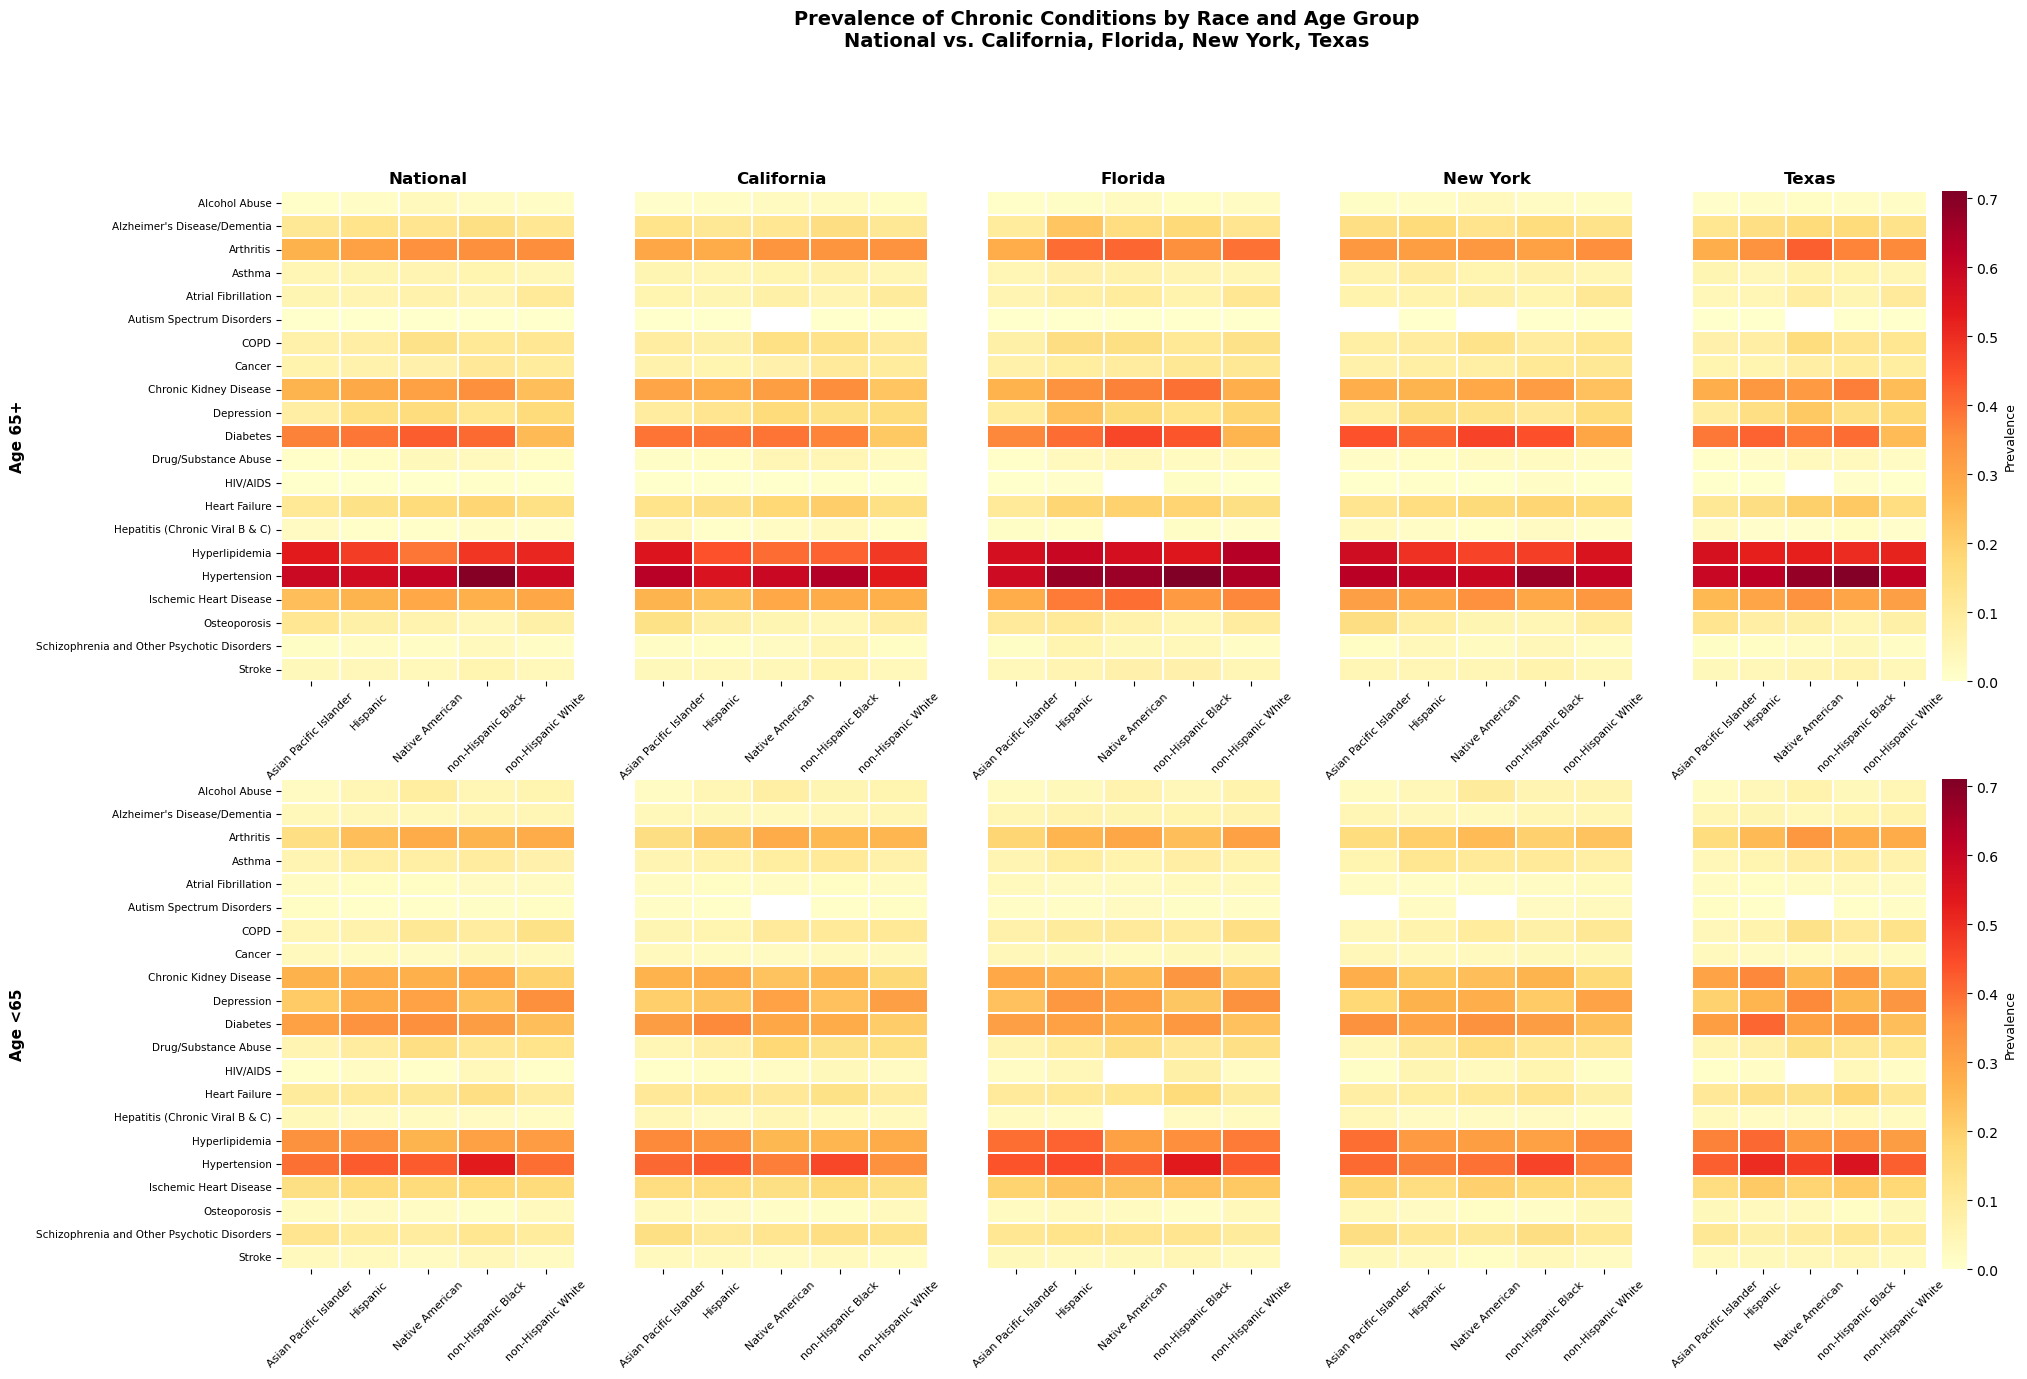

In [6]:
# Save and display the figure
fig.savefig('obj1_prevalence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Objective 2: Medicare Utilization Analysis

### Overview
This section compares four Medicare utilization metrics across all 21 chronic conditions for the **national level** as well as four target states - **Texas, New York, California, and Florida**. The metrics analyzed are:
- **Standardized Per Capita Spending** ('Tot_Mdcr_Stdzd_Pymt_PC'): Adjusted for geographic cost differences
- **Actual Per Capita Spending** ('Tot_Mdcr_Pymt_PC'): Unadjusted total Medicare payments
- **Hospital Readmission Rate** ('Hosp_Readmsn_Rate'): 30-day readmission as a fraction of all admissions
- **ER Visits per 1000 Beneficiaries** ('ER_Visits_Per_1000_Benes')

Only overall ('All') age and demographic rows are used so that comparisons reflect the full beneficiary population.

### Visualization: Bar Chart - Utilization Metrics by Condition and Geography

Each of the four subplots shows one utilization metric. Within each subplot, chronic conditions are sorted from highest to lowest national value, and grouped bars compare the National average against the four states. This layout makes it straightforward to identify which conditions drive the greatest burden and where state-level utilization diverges from the national baseline.

**Key Observations to look for:**
- **Spending (Standardized vs. Actual Per Capita):**
    - Stroke and Heart Failure ranked as the highest-spending conditions under standardized per capita spending, with all four states closely tracking the national average.
    - In the actual per capita spending subplot, California and New York consistently show higher bars than the national average across most conditions, reflecting higher geographic costs that get adjusted away in the standardized metric.
    - Autism Spectrum Disorders and Hyperlipidemia rank among the lowest-spending conditions in both spending subplots
- **Hospital Readmission Rate:**
    - Hepatitis (Chronic Viral B & C) and HIV/AIDS have the highest 30-day readmission rates nationally, which is notably different from the spending rankings where Stroke and Heart Failure lead.
    - Florida consistently shows elevated readmission rates relative to the national average across most conditions, while California tends to fall at or below it.
- **ER Visits per 1000 Beneficiaries:**
    - Drug/Substance Abuse and Alcohol Abuse drive the highest ER visit rates by a wide margin, far exceeding conditions like Stroke and Heart Failure that dominate the spending metrics.
    - New York and Florida show notably higher ER visit bars compared to the national average for the top conditions, suggesting heavier emergency care utilization in those states.

#### Prepare Medicare Utilization Data 

In [7]:
# Extract Data
util_subset_df = df[
    (df['Bene_Age_Lvl'] == 'All') & (df['Bene_Demo_Lvl'] == 'All') & (df['Bene_Demo_Desc'] == 'All') &
    (
        ((df['Bene_Geo_Lvl'] == 'National')) |
        ((df['Bene_Geo_Lvl'] == 'State') & (df['Bene_Geo_Desc'].isin(target_geos)))
    )
]

In [8]:
# Set colors for each geography description
geo_colors = {
    'National':   '#2C3E50',
    'California': '#E74C3C',
    'Florida':    '#3498DB',
    'New York':   '#2ECC71',
    'Texas':      '#F39C12'
}

In [9]:
# list all 4 utilization metrics
util_metrics = [
    'Tot_Mdcr_Stdzd_Pymt_PC', 
    'Tot_Mdcr_Pymt_PC', 
    'Hosp_Readmsn_Rate', 
    'ER_Visits_Per_1000_Benes'
]

#### Barplot

In [10]:
# Setting up the plot
fig, axes = plt.subplots(2, 2, figsize=(24, 18), constrained_layout=True)
# Covert to 1D array for easier iteration
axes_flat = axes.flatten()

In [11]:
# Define plotting parameters
n_geos  = len(target_geos)
bar_width = 0.14
x = np.arange(21)

In [12]:
# Plotting the barplots
for subplot_idx, metric_col in enumerate(util_metrics):
    subplot = axes_flat[subplot_idx]

    # Sort Conditions by metric value 
    cond_ranked_by_metric = (
        util_subset_df[util_subset_df['Bene_Geo_Desc'] == 'National']
        .sort_values(metric_col, ascending = False)['Bene_Cond']
        .tolist()
    )

    # Loop over geographies
    for geo_idx, geo in enumerate(target_geos):
        # filter util_data for current geography, indexed by condition
        subset = util_subset_df[util_subset_df['Bene_Geo_Desc'] == geo].set_index('Bene_Cond')
        # list of metric values (Uses np.nan if condition is missing for a geography)
        values = [subset.loc[c, metric_col] if c in subset.index else np.nan for c in cond_ranked_by_metric]
        # Centers the grouped bars around the x-tick for each condition
        offset = (geo_idx - (n_geos - 1) / 2) * bar_width

        # Draw the bars
        subplot.bar(
            x + offset, 
            values,
            width = bar_width, 
            color = geo_colors[geo], 
            label = geo, 
            alpha = 0.88, 
            edgecolor = 'white', 
            linewidth = 0.4
        )

    # Set ticks, labels, titles
    subplot.set_xticks(x)
    subplot.set_xticklabels(cond_ranked_by_metric, rotation=45, ha='right', fontsize=8.5)
    subplot.set_ylabel(metric_col, fontsize=10)
    subplot.set_title(metric_col, fontsize=11, fontweight='bold')
    subplot.yaxis.grid(True, linestyle='--', alpha=0.6)
    subplot.set_axisbelow(True)

# Single legend below all subplots
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    loc='lower center',
    ncol=5,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

# Add overall title
fig.suptitle(
    'Medicare Utilization Metrics by Chronic Condition\n' 
    'National vs. California, Florida, New York, Texas',
    fontsize=14, fontweight='bold'
)

Text(0.5, 0.98, 'Medicare Utilization Metrics by Chronic Condition\nNational vs. California, Florida, New York, Texas')

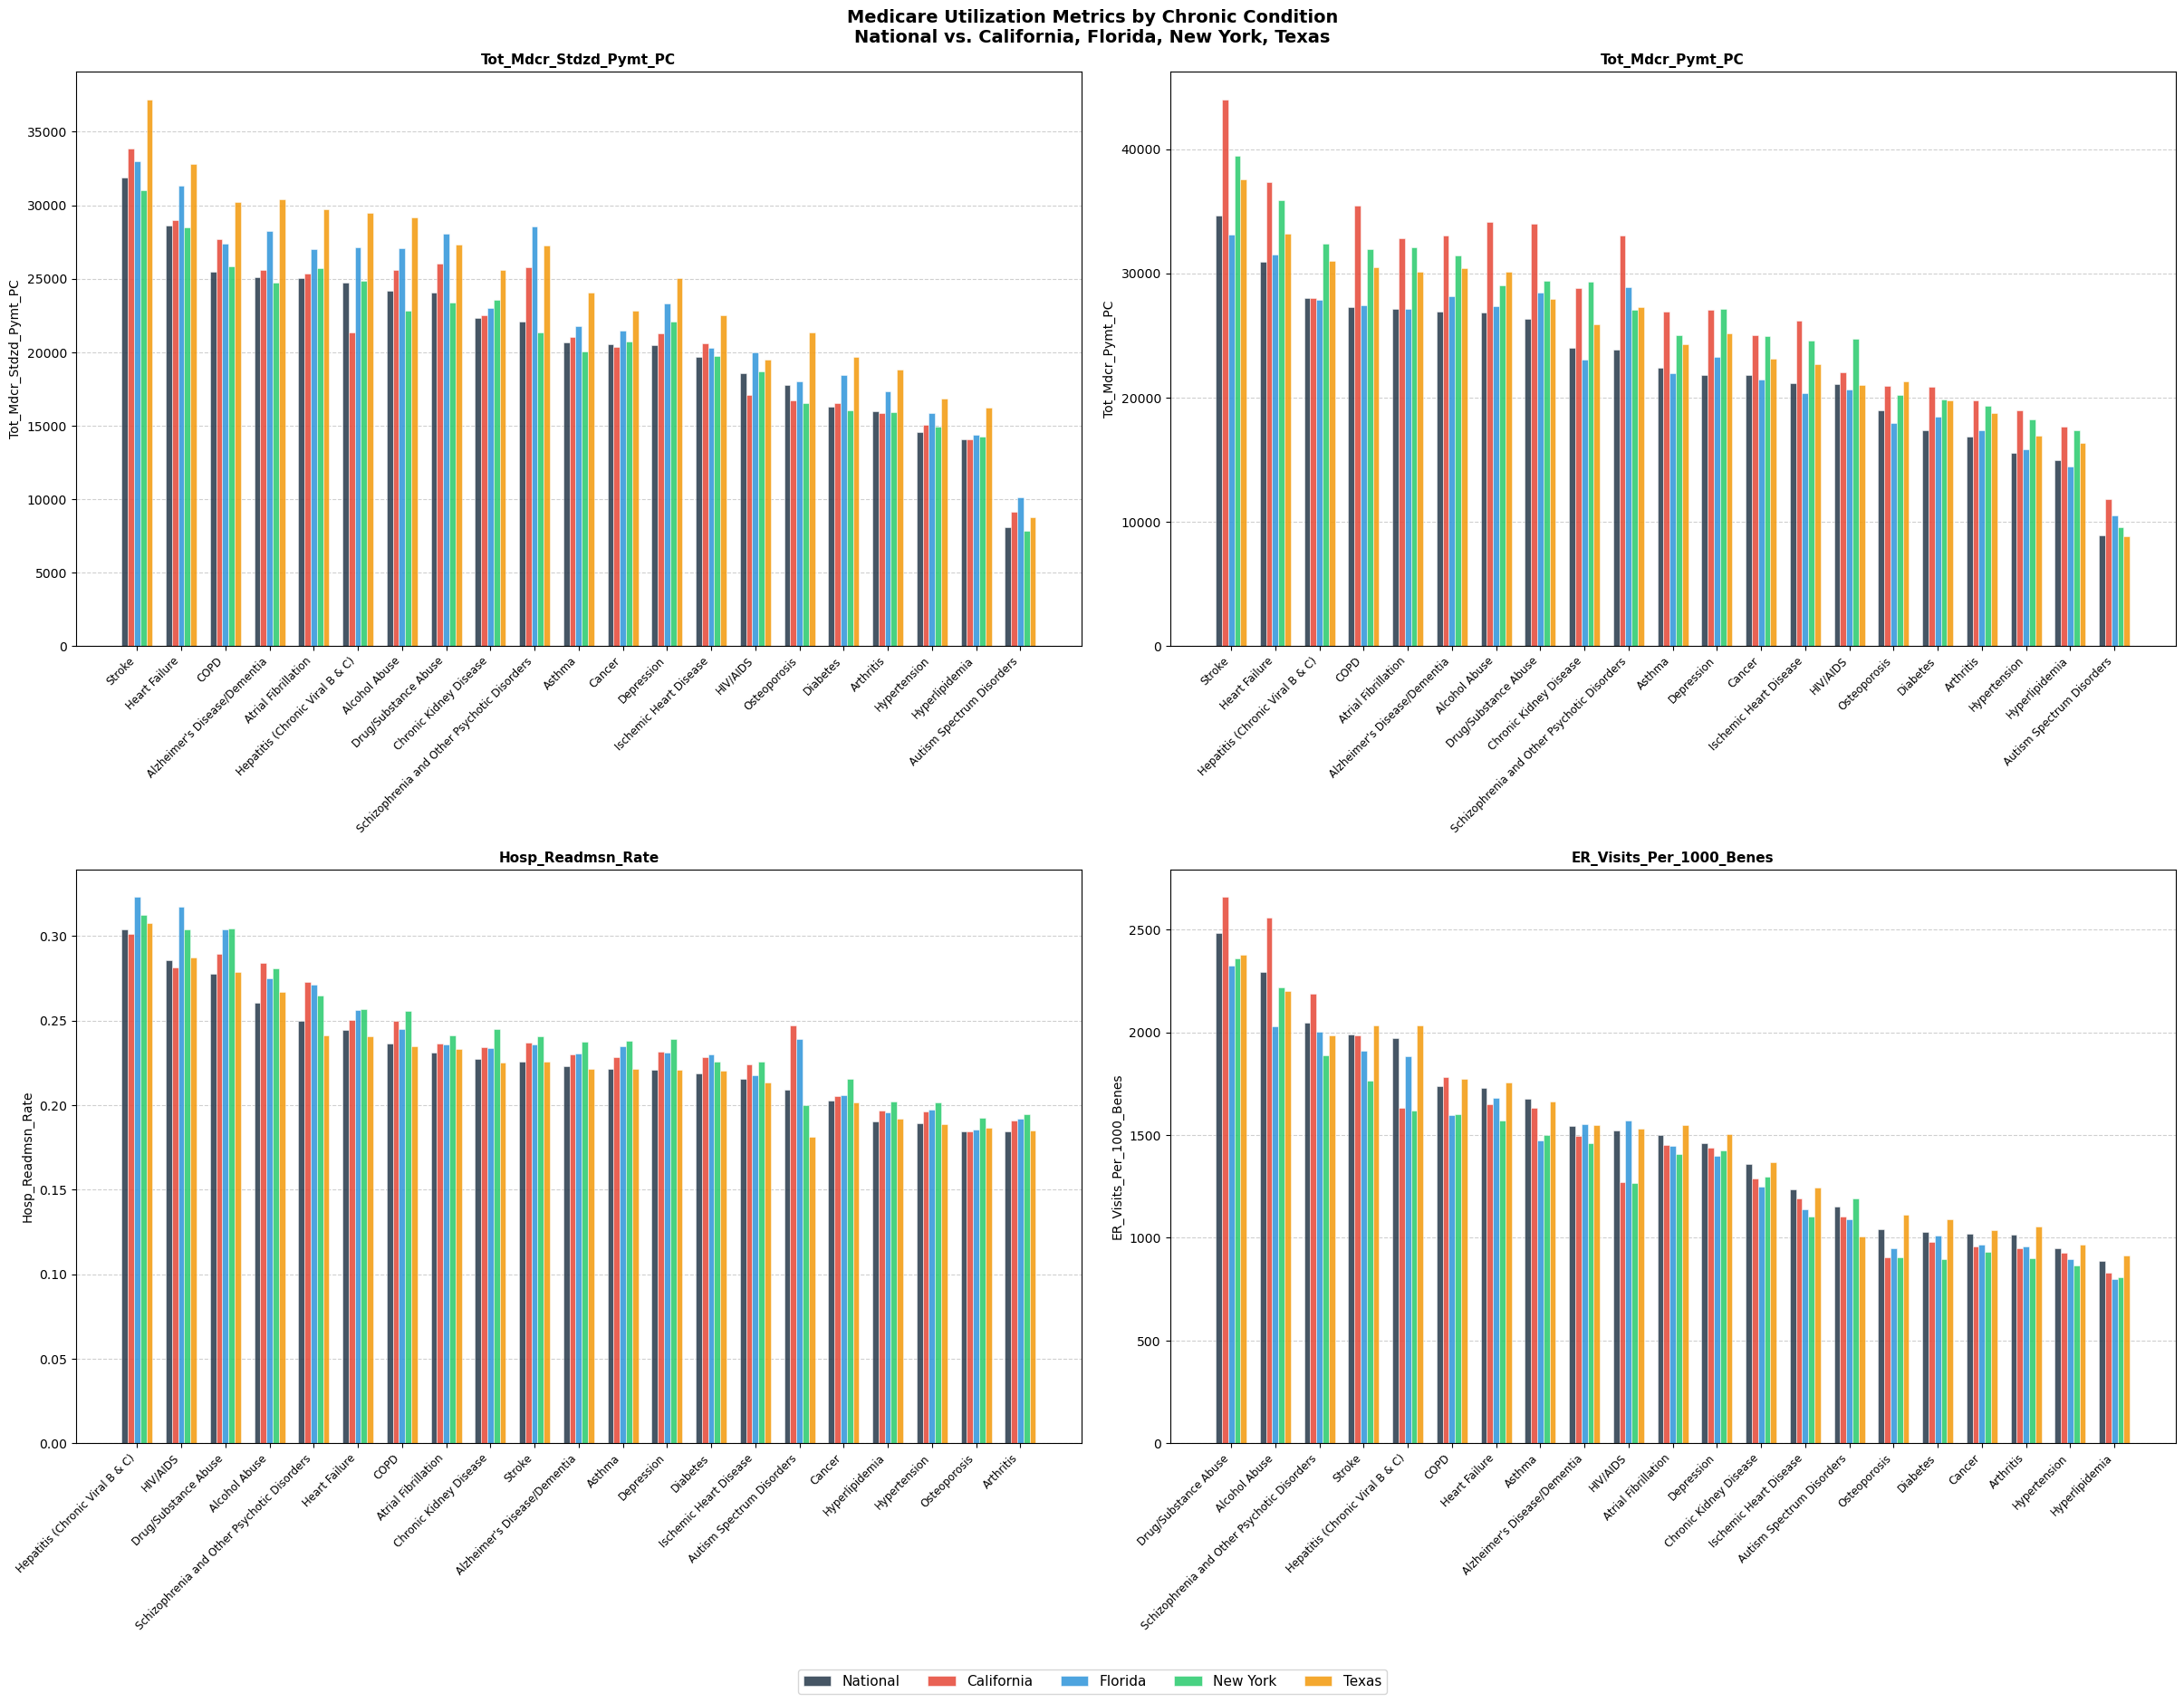

In [13]:
plt.savefig('obj2_utilization_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show() 

---
## Objective 3: State-wise Prevalence Analysis

### Overview
This section identifies which states have the **highest and lowest prevalence rates** for each of the 21 chronic conditions relative to the national average. The analysis is stratified by **gender** (Male, Female) and **race** (Asian Pacific Islander, Hispanic, Native American, non-Hispanic Black, non-Hispanic White).

### Visualization: Diverging Bar Chart - Prevalence by Race and Gender

The figure below displays a divering horizontal bar chart for each chronic condition produced twice, once stratified by **gender** and once by **race**, to allow comparison across both demographic dimensions. For each condition, the single state with the highest mean deviation above the national average and the single state with the lowest mean deviation below the national average are selected based on the average deviation across all demographic groups within that stratification. Each bar represents on demographic group's deviation from its own group-specific national baseline. Bar length corresponds to the absolute difference in prevalence percentage points from the national baseline (dashed vertical line at 0.

**Key Observations to look for:**
- **Gender (Male vs. Female):**
    - For most conditions, male and female deviation move in the same direction for the top and bottom states, suggesting that geographic patterns in chronic disease prevalence are generally consistent across gender rather than being driven by one sex alone.
    - Notable exceptions include Depression and Osteoporosis, where Female beneficiaries show larger positive deviations than Male in the top states, reflecting the well-established higher burden of these conditions among women.
    - For HIV/AIDS, the District of Columbia stands out as the highest state with a substantially larger deviation for Male beneficiaries compared to Female, while North Dakota shows the opposite pattern at the bottom.
- **Race:**
    - Native American beneficiaries (purple) consistently show some of the most extreme deviations, both positive and negative, across conditions like Diabetes, COPD, and Chronic Kidney Disease, indicating this group experiences the greatest geographic variability in chronic disease burden.
    - For Diabetes, Puerto Rico has the highest positive deviation driven largely by Hispanic beneficiaries, while Vermont shows the largest negative deviation, suggesting strong geographic and racial concentration of this condition.
    - Asian Pacific Islander beneficiaries (green) tend to show smaller deviations overall compared to other racial groups, indicating more uniform prevalence across states relative to their national baseline.
    - Virgin Islands appears frequently as the bottom state across multiple conditions and racial groups, which may reflect data suppression or smaller population sizes rather than truly lower disease burden.

#### Function for Diverging Bar Chart

In [20]:
def plot_diverging_top_bottom(df, demo_lvl, demo_descs, demo_label, demo_colors, filename = 'diverging.png'):
    """
    Plots a diverging horizontal bar chart showing the top and bottom states for each chronic 
    condition's prevalence deviation from the national average, stratified by a specified demographic group.

    Parameters:
    - df: pd.DataFrame
        The full chronic disease dataset containing columns: Bene_Geo_Lvl,
        Bene_Geo_Desc, Bene_Demo_Lvl, Bene_Demo_Desc, Bene_Age_Lvl,
        Bene_Cond, and Prvlnc.
    - demo_lvl : str
        The demographic level to filter on. Must match a value in the
        Bene_Demo_Lvl column (e.g. 'Gender' or 'Race').
    - demo_descs : list of str
        The demographic groups to include. Must match values in the
        Bene_Demo_Desc column (e.g. ['Male', 'Female'] or
        ['Hispanic', 'non-Hispanic Black', ...]).
    - demo_label : str
        Label used in the figure title to describe the stratification
        (e.g. 'Gender' or 'Race/Ethnicity').
    - demo_colors : dict
        Mapping of each demographic group in demo_descs to a color string
        (e.g. {'Male': '#3498DB', 'Female': '#E74C3C'}).
    - filename : str, optional
        Output filename for the saved figure. Defaults to 'diverging.png'.

    Returns
    -------
    None: Saves the figure to the specified filename and displays it inline.
    """

    # National baseline per condition per demographic group
    national_baseline = df[
        (df['Bene_Geo_Lvl'] == 'National') &
        (df['Bene_Demo_Lvl'] == demo_lvl) & (df['Bene_Demo_Desc'].isin(demo_descs)) &
        (df['Bene_Age_Lvl'] == 'All')
    ][['Bene_Cond', 'Bene_Demo_Desc', 'Prvlnc']].rename(columns={'Prvlnc': 'nat_avg'})

    # State prevalence per condition per demographic group
    state_prvlnc = df[
        (df['Bene_Geo_Lvl'] == 'State') &
        (df['Bene_Demo_Lvl'] == demo_lvl) & (df['Bene_Demo_Desc'].isin(demo_descs)) &
        (df['Bene_Age_Lvl'] == 'All')
    ][['Bene_Geo_Desc', 'Bene_Cond', 'Bene_Demo_Desc', 'Prvlnc']]

    # Merge on both condition and demographic group
    merged = state_prvlnc.merge(national_baseline, on=['Bene_Cond', 'Bene_Demo_Desc'])
    merged['deviation'] = (merged['Prvlnc'] - merged['nat_avg']) * 100

    # Define plotting parameters
    conditions = sorted(merged['Bene_Cond'].unique())
    n_conds = len(conditions)
    n_groups = len(demo_descs)
    bar_height = 0.8 / n_groups

    # Layout: 3 columns
    n_cols = 3
    n_rows = int(np.ceil(n_conds / n_cols))

    # Setting up plot
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(20, n_rows * 3.2),
        constrained_layout=True
    )
    axes_flat = axes.flatten()

    for i, cond in enumerate(conditions):
        subplot = axes_flat[i]
        cond_data = merged[merged['Bene_Cond'] == cond]

        # Rank states by mean deviation across ALL demographic groups, take top and bottom 1
        state_rank = cond_data.groupby('Bene_Geo_Desc')['deviation'].mean()
        selected_states = state_rank.nsmallest(1).index.tolist() + state_rank.nlargest(1).index.tolist()

        plot_df = cond_data[cond_data['Bene_Geo_Desc'].isin(selected_states)]

        # Sort by mean deviation for y-axis ordering
        state_order = (
            plot_df.groupby('Bene_Geo_Desc')['deviation'].mean()
            .sort_values()
            .index.tolist()
        )

        y_positions = np.arange(len(state_order))

        for grp_idx, group in enumerate(demo_descs):
            group_df = (
                cond_data[cond_data['Bene_Demo_Desc'] == group]
                .set_index('Bene_Geo_Desc')
            )
            values = [
                group_df.loc[s, 'deviation'] if s in group_df.index else np.nan
                for s in state_order
            ]
            offset = (grp_idx - (n_groups - 1) / 2) * bar_height

            subplot.barh(
                y_positions + offset,
                values,
                height = bar_height,
                color = demo_colors[group],
                label = group,
                alpha = 0.85,
                edgecolor = 'white',
                linewidth = 0.3
            )

        subplot.set_yticks(y_positions)
        subplot.set_yticklabels(state_order, fontsize = 6.5)
        subplot.axvline(0, color='black', linewidth = 0.9, linestyle = '--')
        subplot.set_title(cond, fontsize = 9, fontweight = 'bold', pad = 3)
        subplot.set_xlabel('Percentage Points (%) vs. National Avg', fontsize = 7.5)
        subplot.tick_params(axis='y', labelsize = 7.5)
        subplot.tick_params(axis='x', labelsize = 7.5)
        subplot.xaxis.grid(True, linestyle = ':', alpha = 0.5)
        subplot.set_axisbelow(True)

        # Dummy bars for legend on first subplot only
        if i == 0:
            for group in demo_descs:
                subplot.barh([], [], color=demo_colors[group], label=group)

    # Hide empty subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Deduplicate and draw legend
    handles, labels = axes_flat[0].get_legend_handles_labels()
    seen = {}
    for handle, label in zip(handles, labels):
        if label not in seen:
            seen[label] = handle

    fig.legend(
        handles = list(seen.values()),
        labels = list(seen.keys()),
        loc = 'lower center',
        ncol = len(demo_descs),
        fontsize = 9, frameon = True,
        bbox_to_anchor = (0.5, -0.02)
    )

    # Add overall title
    fig.suptitle(
        f'State Prevalence Deviation from National Average — Stratified by {demo_label}\n'
        f'Top & Bottom States per Chronic Condition (Prevalence)',
        fontsize = 13, fontweight = 'bold'
    )

    # Save and Display Plot
    plt.savefig(filename, dpi = 150, bbox_inches = 'tight')
    plt.show()

#### Chart A: Stratified by Gender

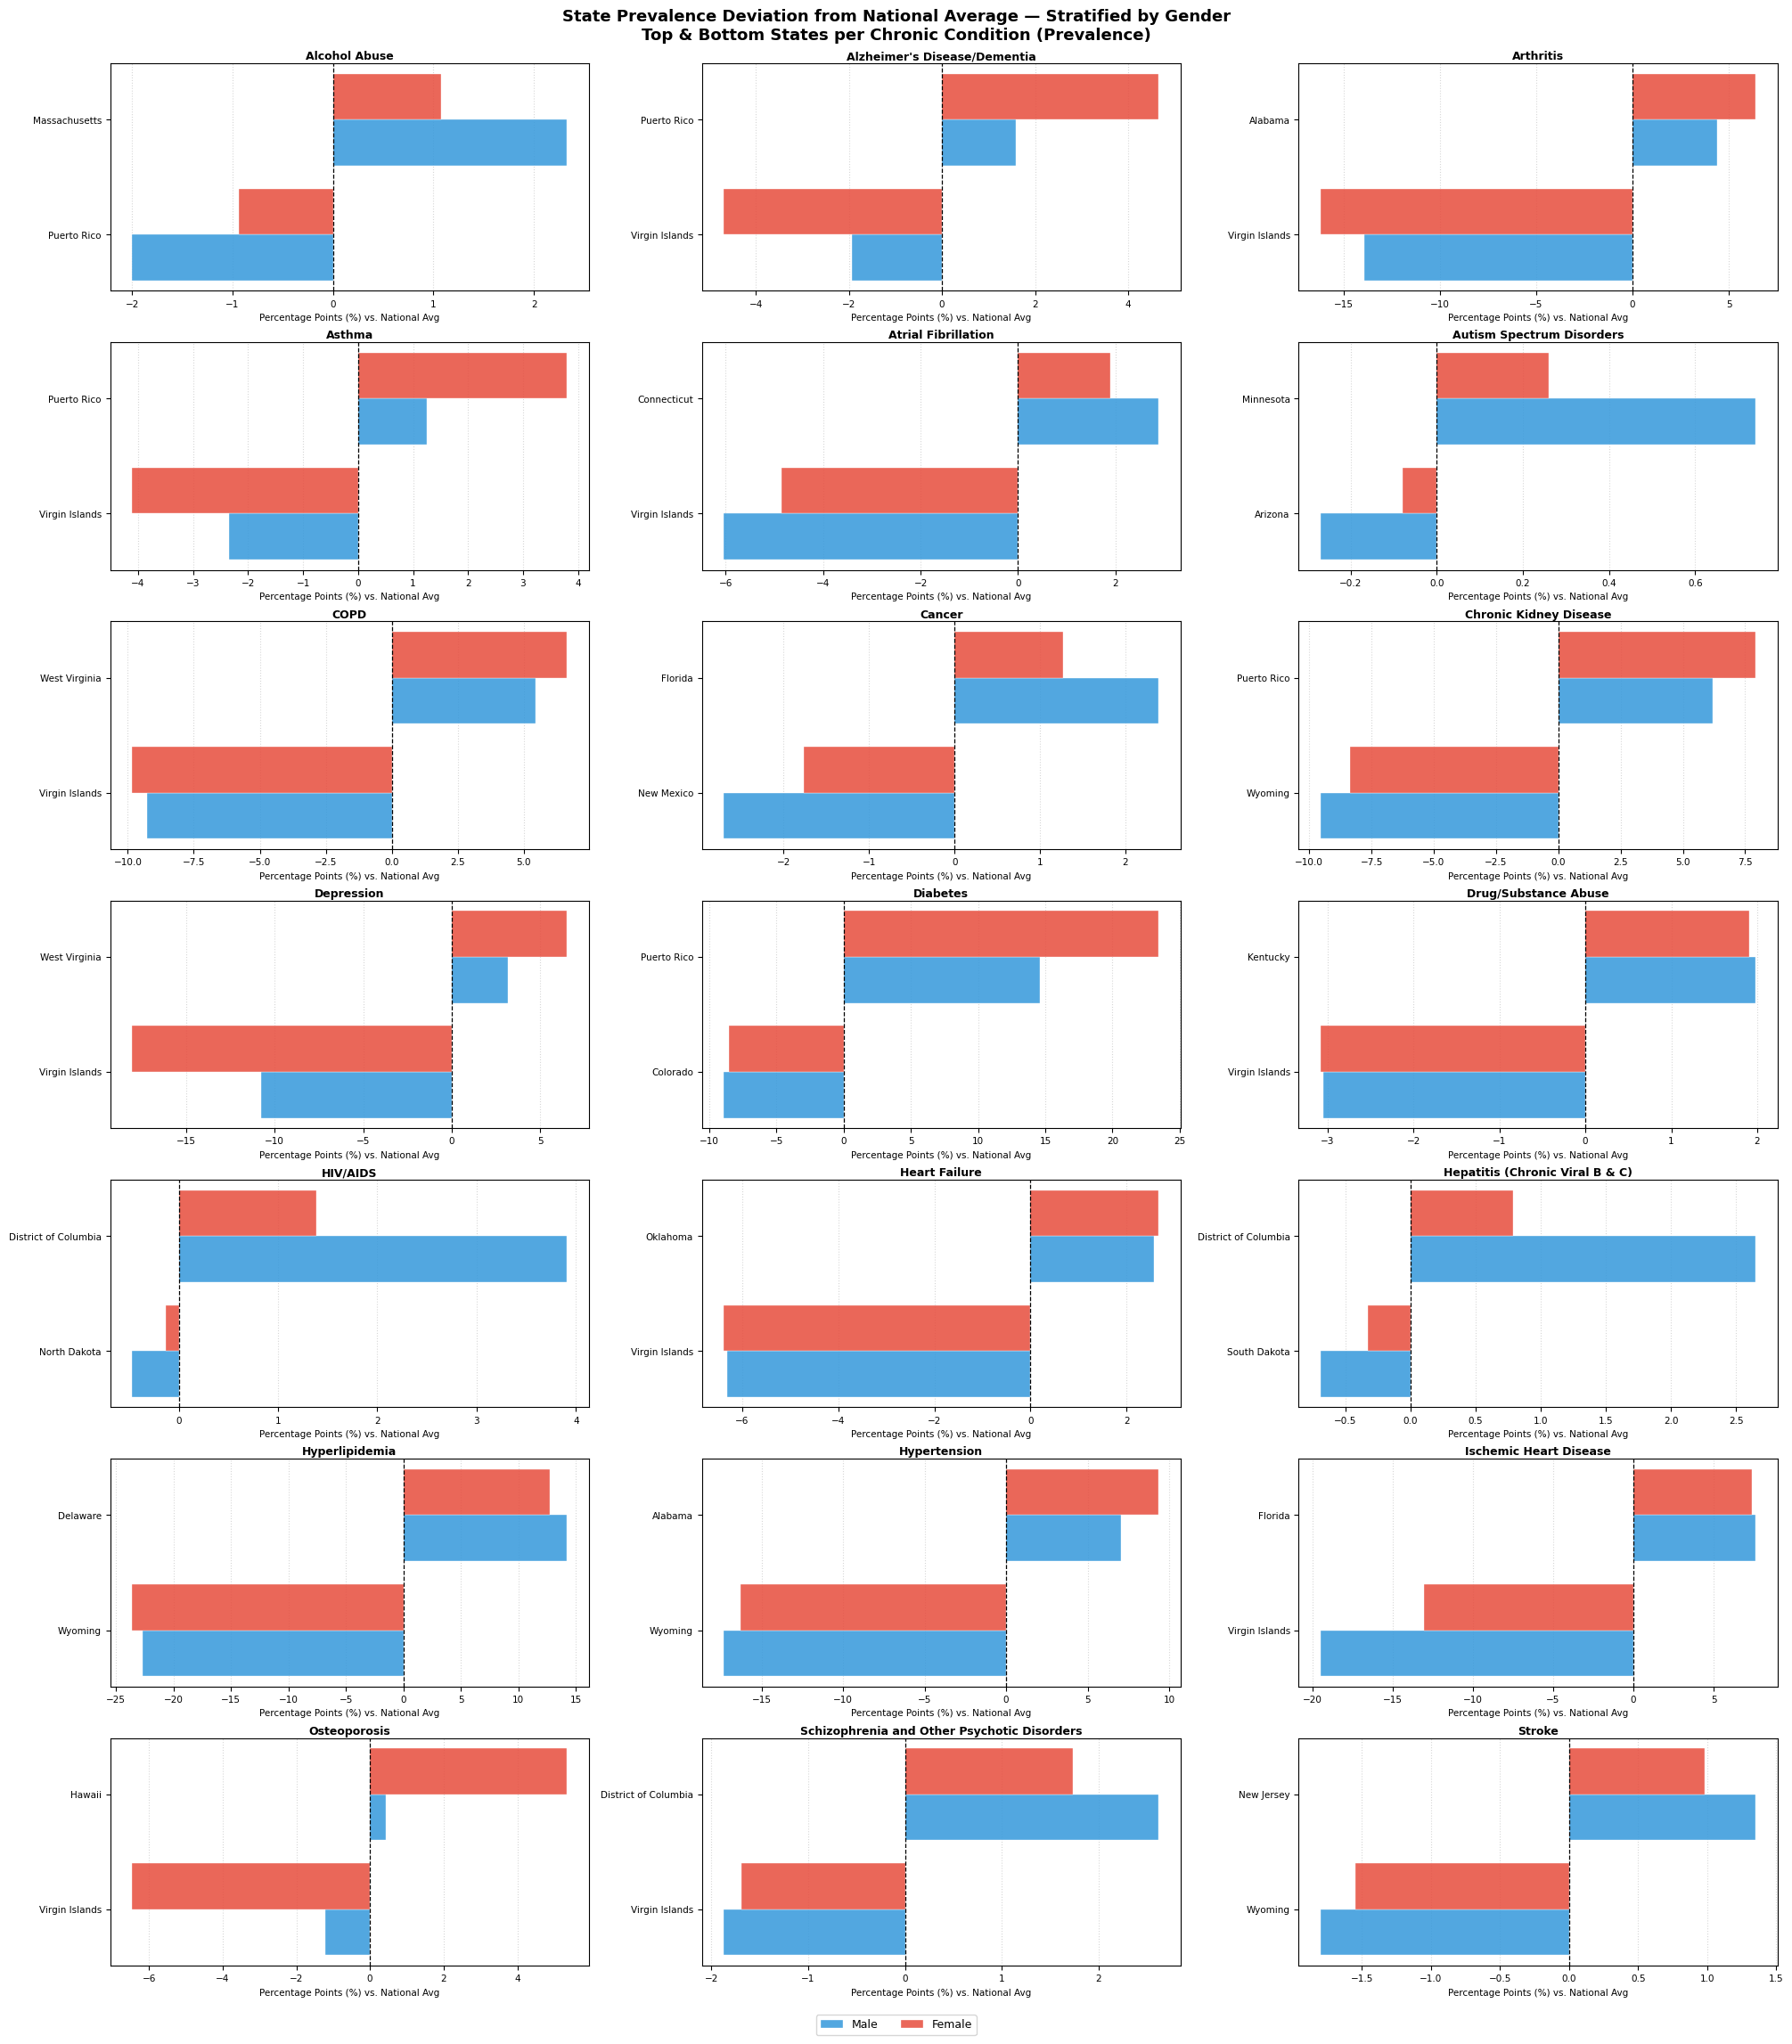

In [15]:
plot_diverging_top_bottom(
    df,
    demo_lvl='Sex',
    demo_descs=['Male', 'Female'],
    demo_label='Gender',
    demo_colors={'Male': '#3498DB', 'Female': '#E74C3C'},
    filename='obj3_diverging_gender.png'
)

#### Chart B: Stratified by Race

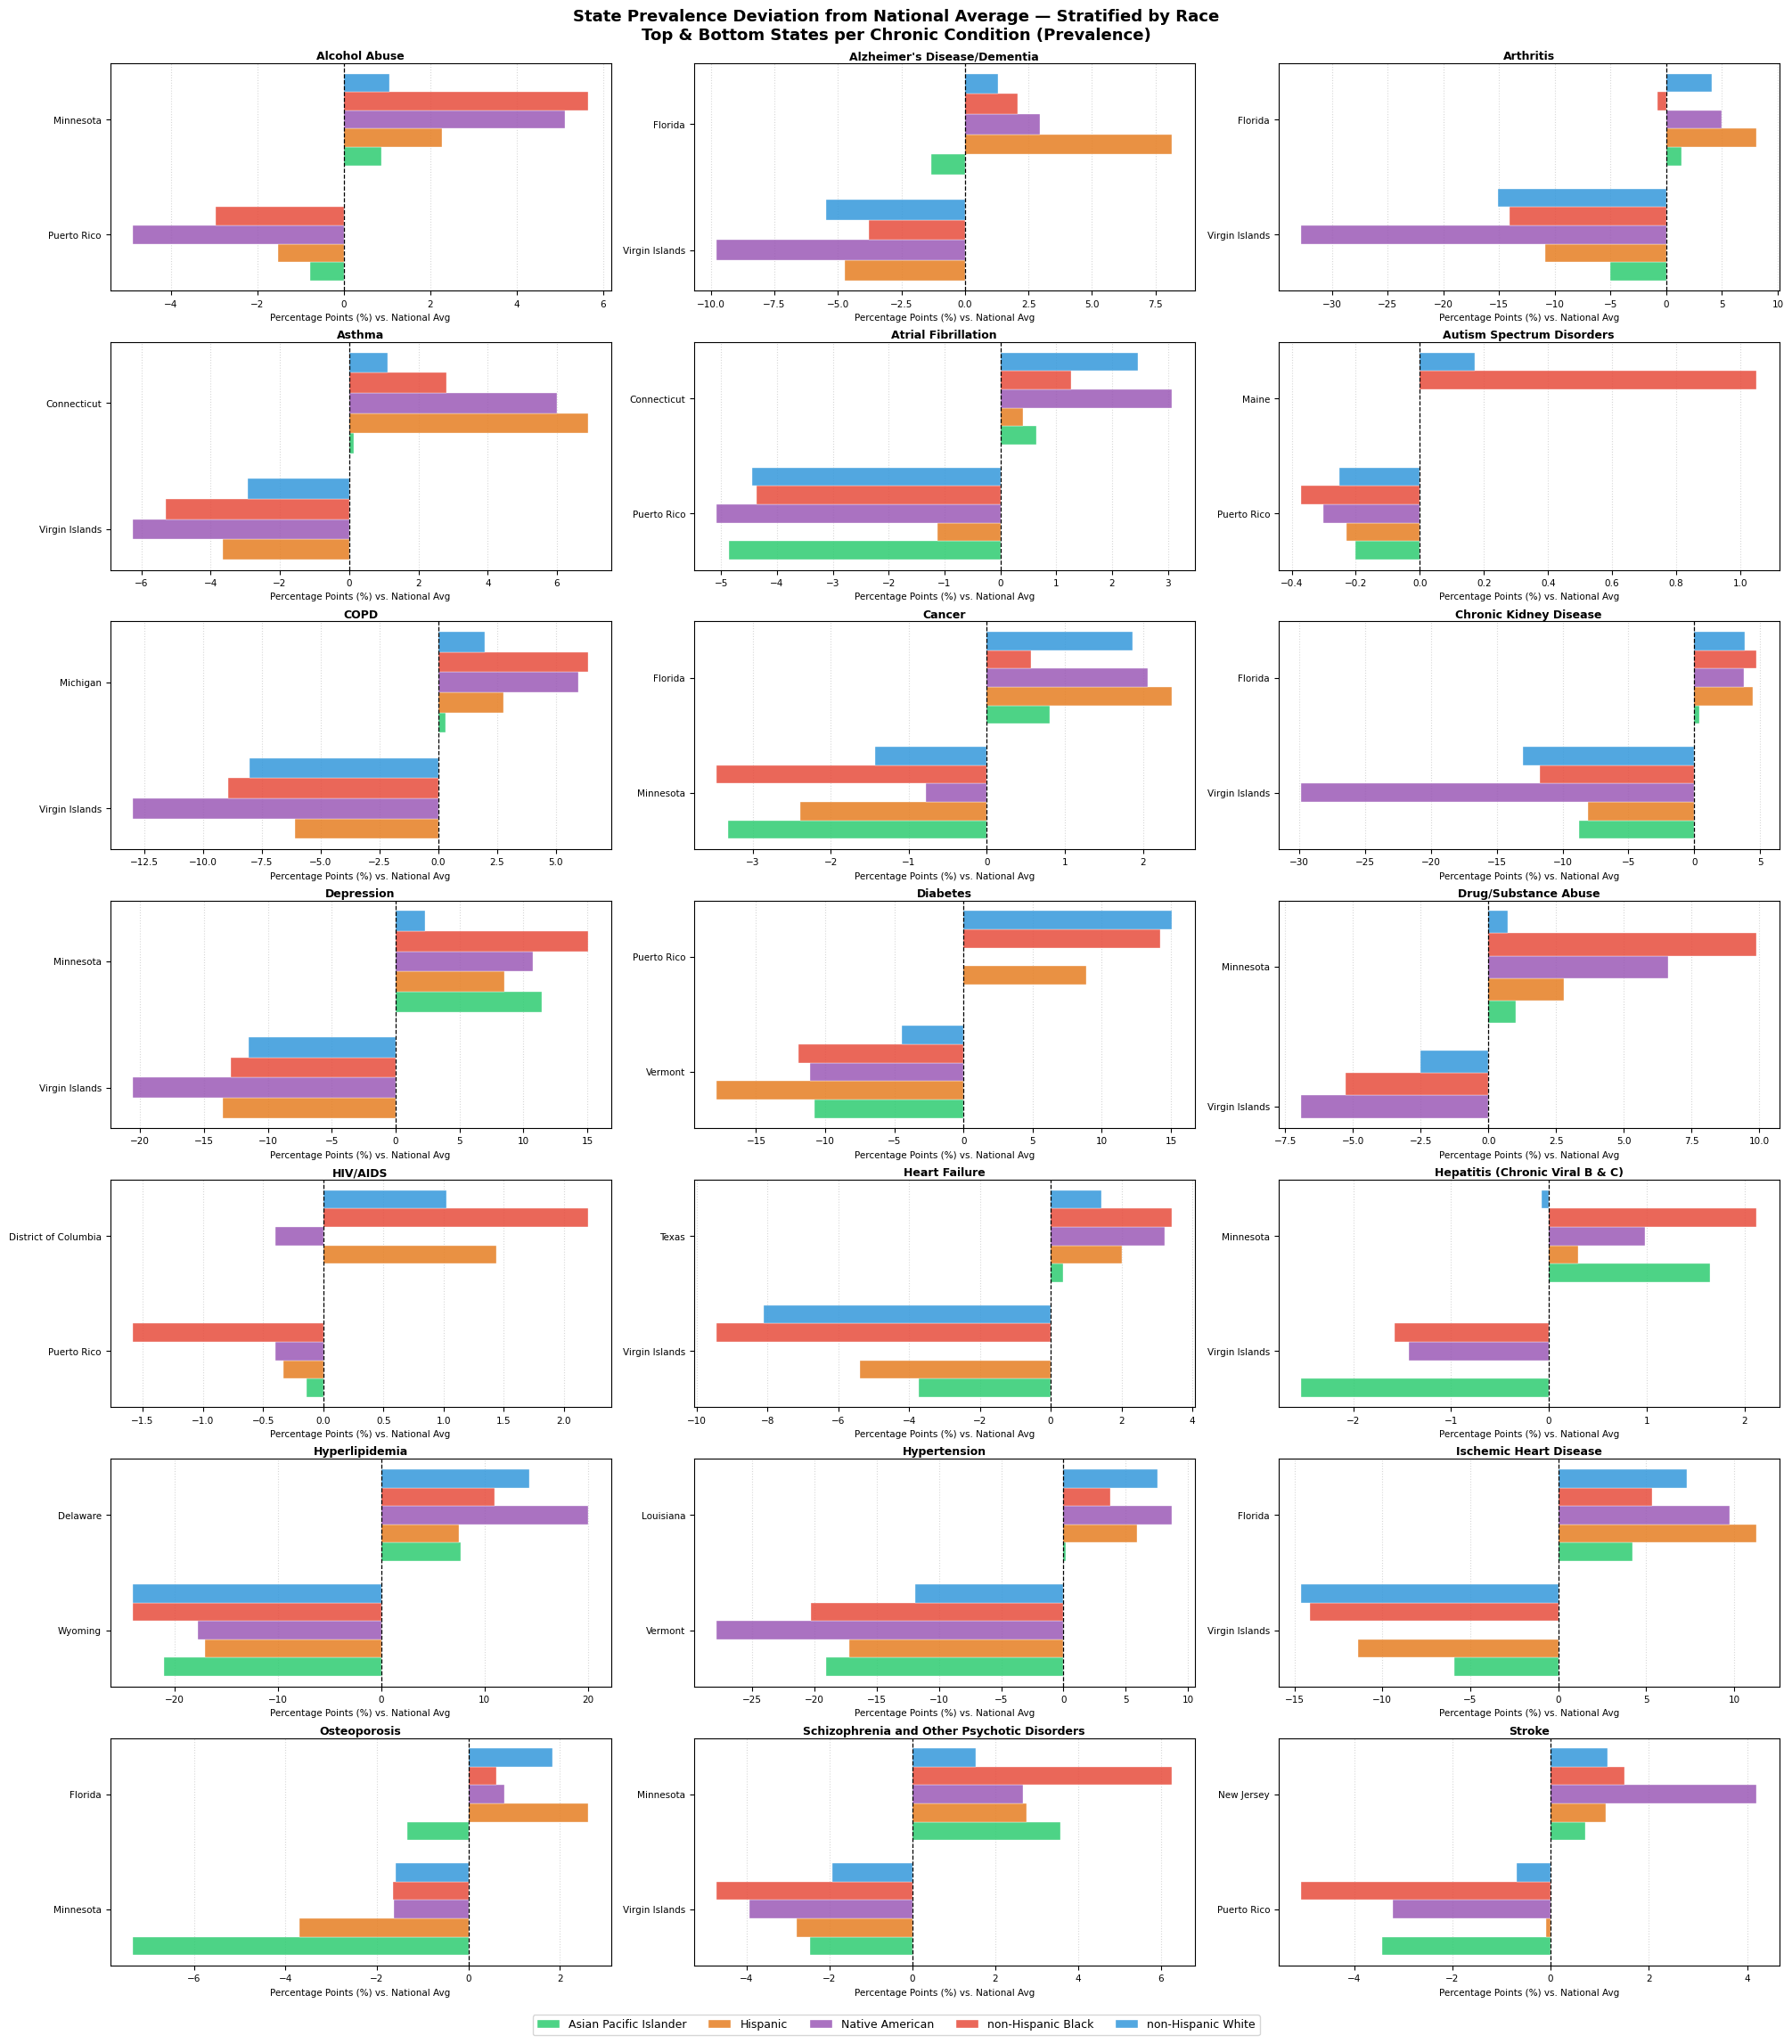

In [17]:
plot_diverging_top_bottom(
    df,
    demo_lvl='Race',
    demo_descs=['Asian Pacific Islander', 'Hispanic', 'Native American', 'non-Hispanic Black', 'non-Hispanic White'],
    demo_label='Race',
    demo_colors={
        'Asian Pacific Islander': '#2ECC71',
        'Hispanic': '#E67E22',
        'Native American': '#9B59B6',
        'non-Hispanic Black': '#E74C3C',
        'non-Hispanic White': '#3498DB'
    },
    filename='obj3_diverging_race.png'
)